# Wheel Life-Curve Analysis — Diameter vs Time & Distance

Exploratory reconstruction of wheel life curves from the **Wheel Engineering State v1.0** dataset
(`model_datasets/v3/wheel_engineering_state_v1.0.parquet`).

- **Each line = one wheelset's** diameter trajectory over time.
- **Turning (reprofiling)** appears as a *sudden diameter drop* (verified: median −5 mm at turning
  events, 70.7% of turning rows drop > 2 mm), after which a new degradation segment begins.
- The progression mirrors the sketch: one loco → short window → grow the window → turnings on/off →
  all wheel lives together (fleet spaghetti) → diameter vs distance → wear rate vs distance →
  remaining material vs distance.

**Caveats (kept honest):**
- The 1016 mm diameter line is a **reference only** — the RDSO limit register is not yet approved.
- The distance axis uses the **RTIS daily-safe cumulative km** (owner-approved aggregation rule,
  `distance_recovery/data/processed/rtis_daily_safe.parquet`), merged per locomotive-date
  (`direction="backward"`). Coverage on measurements is ~75%; the tail without distance is excluded
  from distance plots.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _find_root():
    cwd = Path.cwd()
    for cand in [cwd, cwd.parent]:
        if (cand / "model_datasets" / "v3").exists():
            return cand
    raise FileNotFoundError("Could not locate project root")
ROOT = _find_root()

WES_PATH = ROOT / "model_datasets" / "v3" / "wheel_engineering_state_v1.0.parquet"
RTIS_PATH = ROOT / "distance_recovery" / "data" / "processed" / "rtis_daily_safe.parquet"

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
CONDEMN_DIA_REF = 1016.0  # reference only, not an approved limit

def cfor(i, name="tab10"):
    return plt.get_cmap(name)(i % plt.get_cmap(name).N)


In [2]:
wes = pd.read_parquet(WES_PATH)
wes["measurement_timestamp"] = pd.to_datetime(wes["measurement_timestamp"])
print(f"WES: {wes.shape[0]:,} rows, {wes['wheelset_equipment_id'].nunique():,} wheelsets")
print(f"date span: {wes['measurement_timestamp'].min():%Y-%m-%d} -> {wes['measurement_timestamp'].max():%Y-%m-%d}")


WES: 271,350 rows, 19,167 wheelsets
date span: 2014-10-31 -> 2026-07-24


In [3]:
def build_timeline(we):
    df = we[we["wsmDia1_quality"] == "OBSERVED_VALID"].copy()
    df = df.sort_values(["wheelset_equipment_id", "measurement_timestamp"]).reset_index(drop=True)
    df["dia"] = df["wsmDia1"]
    df["turning"] = (df["wsmturning1"].fillna(0) == 1).astype(int)
    df["turning_count"] = df.groupby("wheelset_equipment_id")["turning"].cumsum()
    df["seg"] = df.groupby("wheelset_equipment_id")["turning"].cumsum()
    return df

timeline = build_timeline(wes)
print(f"valid-dia rows: {len(timeline):,} | wheelsets: {timeline['wheelset_equipment_id'].nunique():,}")
print(f"turning events: {int(timeline['turning'].sum()):,} | wheelsets with >=1 turning: {(timeline.groupby('wheelset_equipment_id')['turning'].max() == 1).sum():,}")


valid-dia rows: 269,068 | wheelsets: 17,017
turning events: 5,246 | wheelsets with >=1 turning: 2,196


In [4]:
rtis = pd.read_parquet(RTIS_PATH)
rtis["day"] = pd.to_datetime(rtis["day"])
rtis["loco"] = rtis["loco"].astype(str)
rtis = rtis.sort_values(["loco", "day"])
rtis["cum_km"] = rtis.groupby("loco")["rtis_km_safe"].cumsum()

km = rtis[["loco", "day", "cum_km"]].rename(columns={"loco": "LomNumber"})
tl = timeline[["wheelset_equipment_id", "measurement_timestamp", "LomNumber"]].copy()
tl = tl.sort_values("measurement_timestamp")
km = km.sort_values("day")
joined = pd.merge_asof(tl, km, left_on="measurement_timestamp", right_on="day",
                       by="LomNumber", direction="backward")
timeline["cum_km"] = joined["cum_km"]
print(f"measurements with distance available: {timeline['cum_km'].notna().mean():.1%}")


measurements with distance available: 74.8%


## Section 1 — Diameter vs Time

Start small: **one locomotive**, short time window (first 12 months), one line per wheelset.
Then grow the window to the full observed span of the same loco.

In [5]:
def plot_wheels(ax, data, markers=True, lw=1.2, alpha=0.9):
    g = data.groupby("wheelset_equipment_id")
    n = len(g)
    for i, (ws, d) in enumerate(g):
        ax.plot(d["measurement_timestamp"], d["dia"], "-", color=cfor(i),
                lw=lw, alpha=alpha, label=str(ws) if i < 12 else None)
        if markers:
            ax.scatter(d["measurement_timestamp"], d["dia"], s=9, color=cfor(i))
    ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1,
               label=f"{CONDEMN_DIA_REF} mm (reference)")
    ax.set_xlabel("Measurement date")
    ax.set_ylabel("Wheel diameter (mm)")


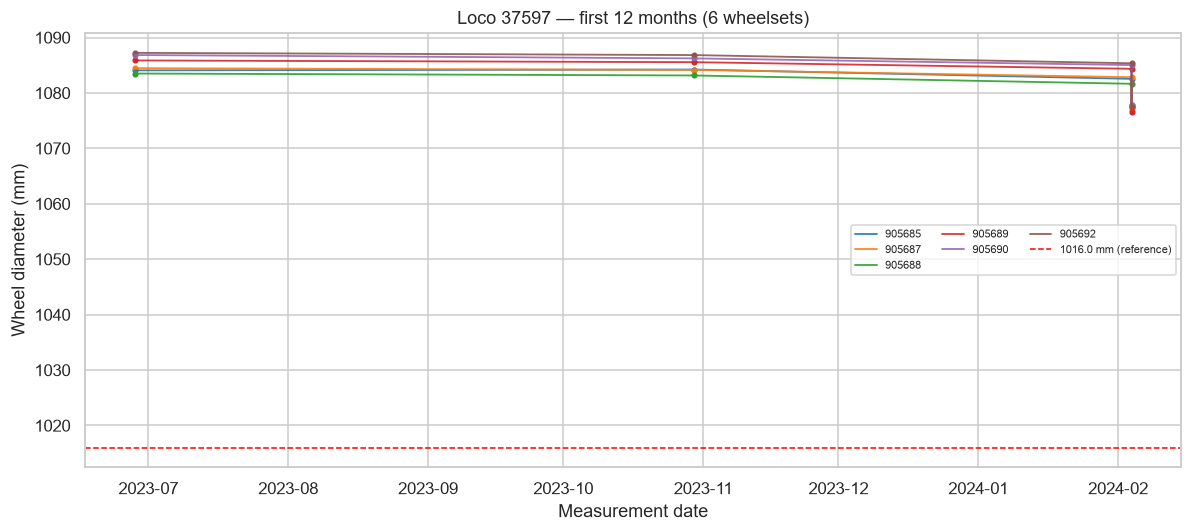

In [6]:
loco = "37597"
one = timeline[timeline["LomNumber"] == loco]
w0 = one["measurement_timestamp"].min()
win = one[(one["measurement_timestamp"] >= w0) & (one["measurement_timestamp"] < w0 + pd.Timedelta(days=365))]

fig, ax = plt.subplots(figsize=(11, 5))
plot_wheels(ax, win)
ax.set_title(f"Loco {loco} — first 12 months ({win['wheelset_equipment_id'].nunique()} wheelsets)")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()


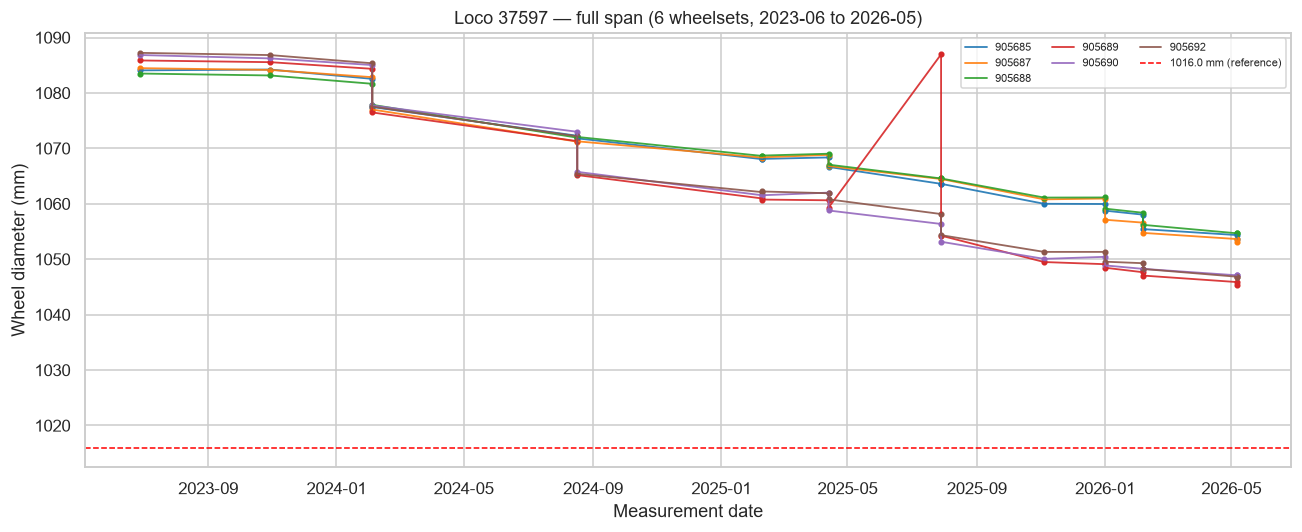

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_wheels(ax, one)
ax.set_title(f"Loco {loco} — full span ({one['wheelset_equipment_id'].nunique()} wheelsets, "
             f"{one['measurement_timestamp'].min():%Y-%m} to {one['measurement_timestamp'].max():%Y-%m})")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()


## Section 2 — Turning (reprofiling) events

Turning removes material, so the diameter **drops suddenly** at a turning event and a new
degradation segment begins. First the plot **with** turning events marked, then the same data
**without** turnings — i.e. each segment (period where the wheel did *not* turn) drawn separately.

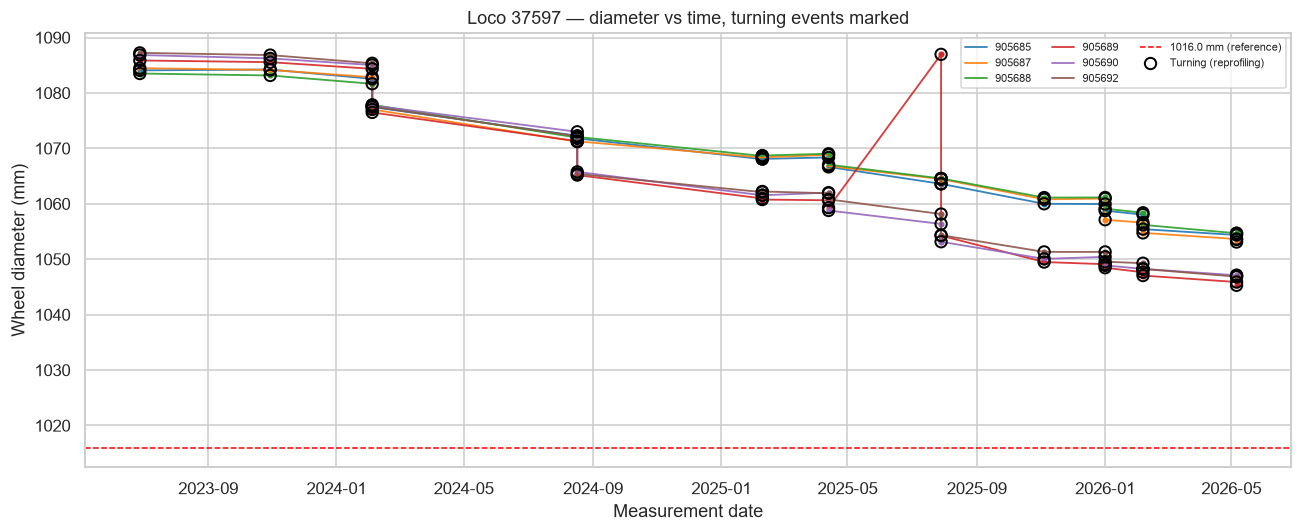

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_wheels(ax, one, markers=True)
tr = one[one["turning"] == 1]
if len(tr):
    ax.scatter(tr["measurement_timestamp"], tr["dia"], marker="o", s=55,
               facecolor="none", edgecolor="black", linewidths=1.3, zorder=5,
               label="Turning (reprofiling)")
ax.set_title(f"Loco {loco} — diameter vs time, turning events marked")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()


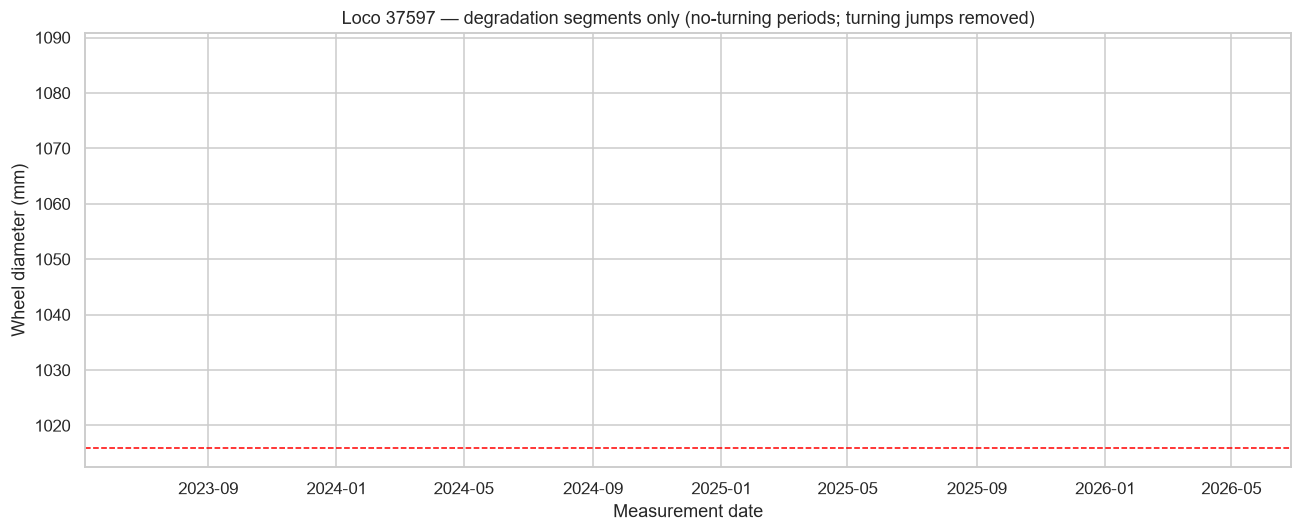

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for ws, d in one.groupby("wheelset_equipment_id"):
    for seg_i, s in d.groupby("seg"):
        ax.plot(s["measurement_timestamp"], s["dia"], "-", lw=1.1, alpha=0.9,
                color=cfor(ws % 10))
ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1)
ax.set_title(f"Loco {loco} — degradation segments only (no-turning periods; turning jumps removed)")
ax.set_xlabel("Measurement date")
ax.set_ylabel("Wheel diameter (mm)")
plt.tight_layout(); plt.show()


## Section 3 — Colour by attribute

Fleet-wide colouring options: cumulative **turning count**, **home shed**, and **wheel profile**.

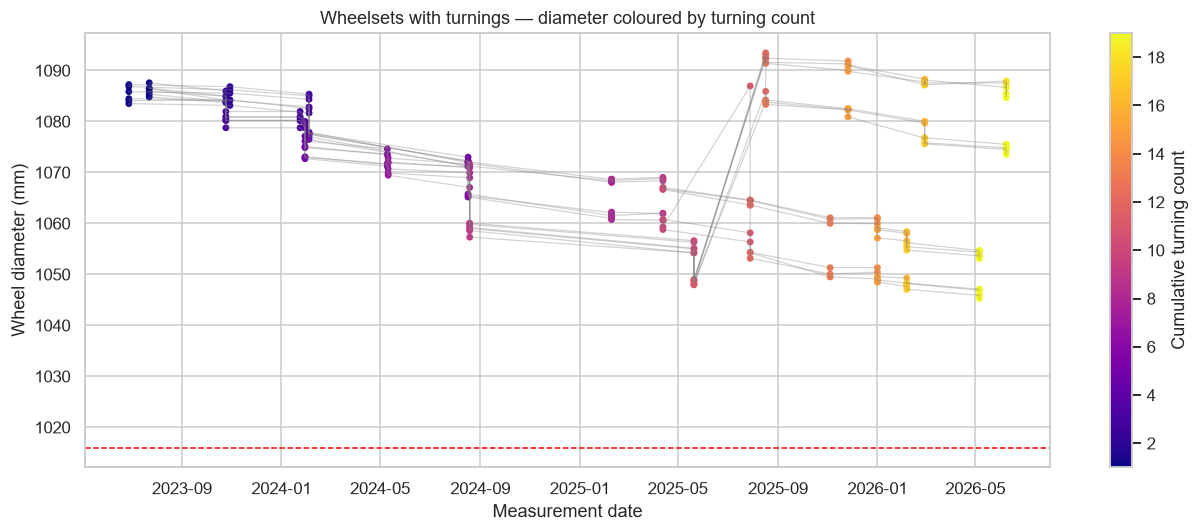

In [10]:
tw = timeline[timeline["turning_count"] >= 1].copy()
top = tw.groupby("wheelset_equipment_id")["turning_count"].max().nlargest(12).index
sample = tw[tw["wheelset_equipment_id"].isin(top)]

fig, ax = plt.subplots(figsize=(12, 5))
for ws, d in sample.groupby("wheelset_equipment_id"):
    ax.plot(d["measurement_timestamp"], d["dia"], lw=0.8, alpha=0.35, color="gray")
sc = ax.scatter(sample["measurement_timestamp"], sample["dia"],
                c=sample["turning_count"], cmap="plasma", s=12)
ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1)
plt.colorbar(sc, ax=ax, label="Cumulative turning count")
ax.set_title("Wheelsets with turnings — diameter coloured by turning count")
ax.set_xlabel("Measurement date"); ax.set_ylabel("Wheel diameter (mm)")
plt.tight_layout(); plt.show()


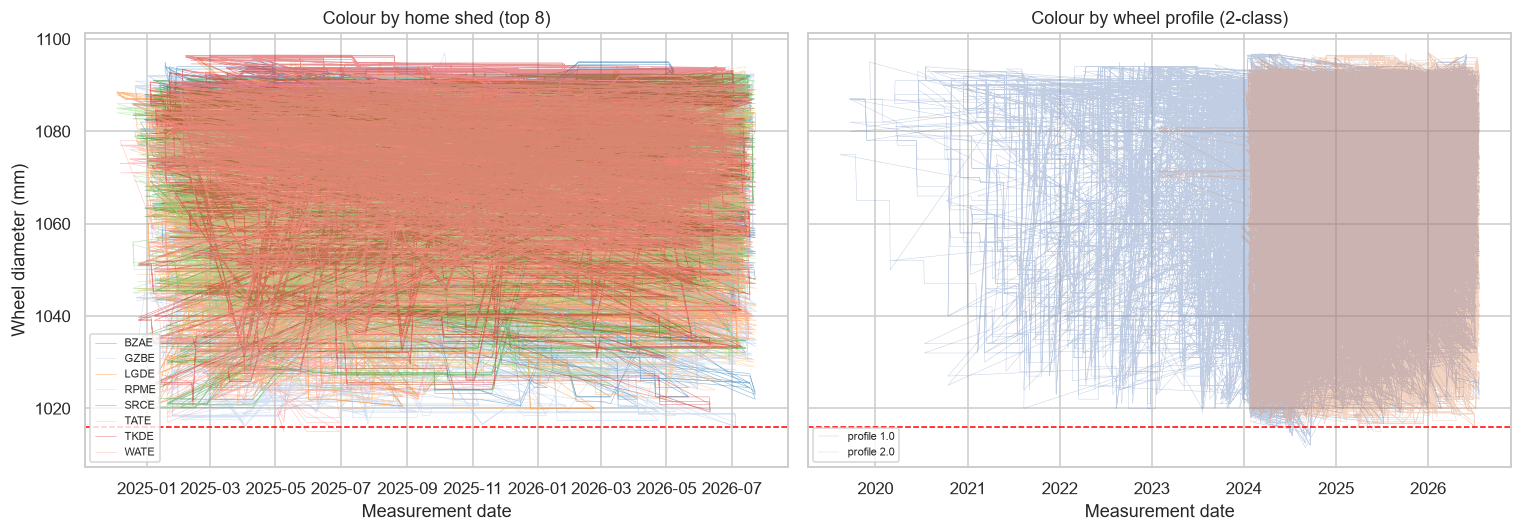

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sub = timeline[timeline["home_shed"].notna()].copy()
sheds = sub["home_shed"].value_counts().head(8).index
for i, (shed, d) in enumerate(sub[sub["home_shed"].isin(sheds)].groupby("home_shed")):
    axes[0].plot(d["measurement_timestamp"], d["dia"], lw=0.4, alpha=0.5,
                 color=cfor(i, "tab20"), label=shed.strip())
axes[0].set_title("Colour by home shed (top 8)")
for prof, d in timeline.dropna(subset=["wheel_profile_2class"]).groupby("wheel_profile_2class"):
    axes[1].plot(d["measurement_timestamp"], d["dia"], lw=0.3, alpha=0.35, label=f"profile {prof}")
axes[1].set_title("Colour by wheel profile (2-class)")
for ax in axes:
    ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1)
    ax.set_xlabel("Measurement date")
axes[0].set_ylabel("Wheel diameter (mm)")
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()


## Section 4 — All wheel lives together (fleet spaghetti)

A random sample of wheelsets, all plotted on one axis, plus the fleet aggregate
(median diameter with a 10–90th percentile band by calendar month).

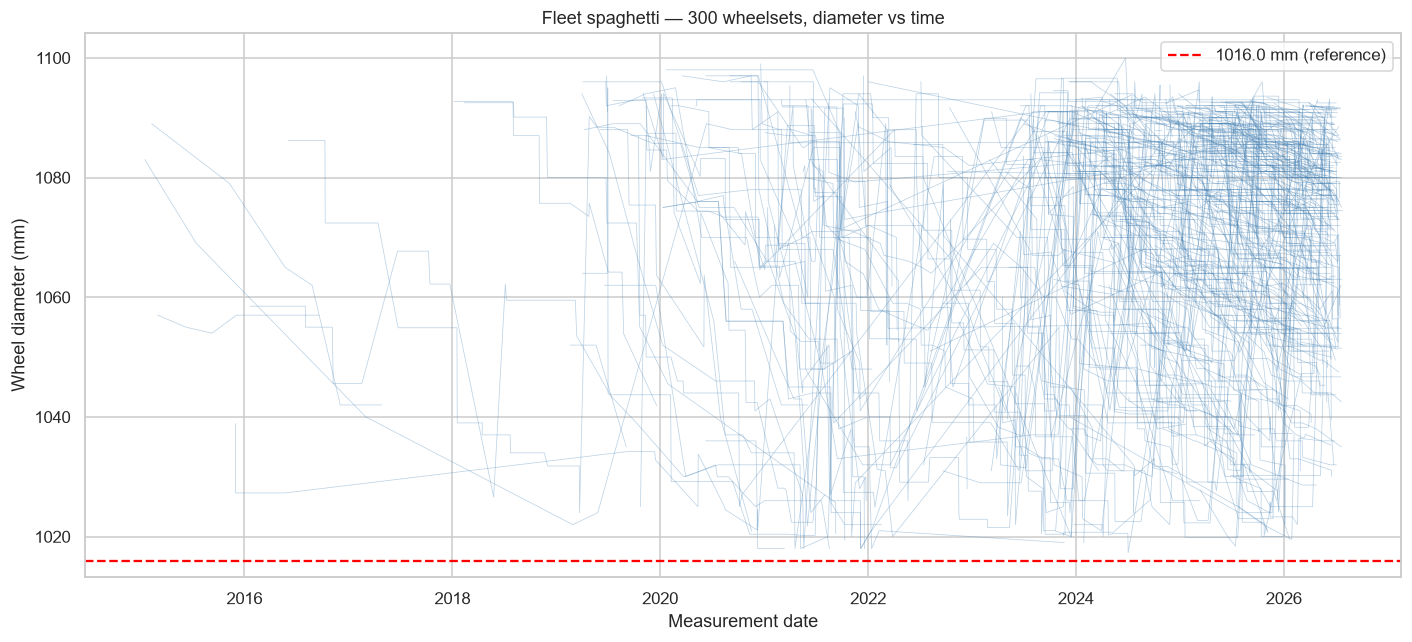

In [12]:
rng = np.random.default_rng(42)
all_ws = timeline["wheelset_equipment_id"].unique()
samp_ws = rng.choice(all_ws, size=min(300, len(all_ws)), replace=False)
samp = timeline[timeline["wheelset_equipment_id"].isin(samp_ws)]

fig, ax = plt.subplots(figsize=(13, 6))
for ws, d in samp.groupby("wheelset_equipment_id"):
    ax.plot(d["measurement_timestamp"], d["dia"], lw=0.5, alpha=0.35, color="steelblue")
ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1.5, label=f"{CONDEMN_DIA_REF} mm (reference)")
ax.set_title(f"Fleet spaghetti — {len(samp_ws)} wheelsets, diameter vs time")
ax.set_xlabel("Measurement date"); ax.set_ylabel("Wheel diameter (mm)")
ax.legend()
plt.tight_layout(); plt.show()


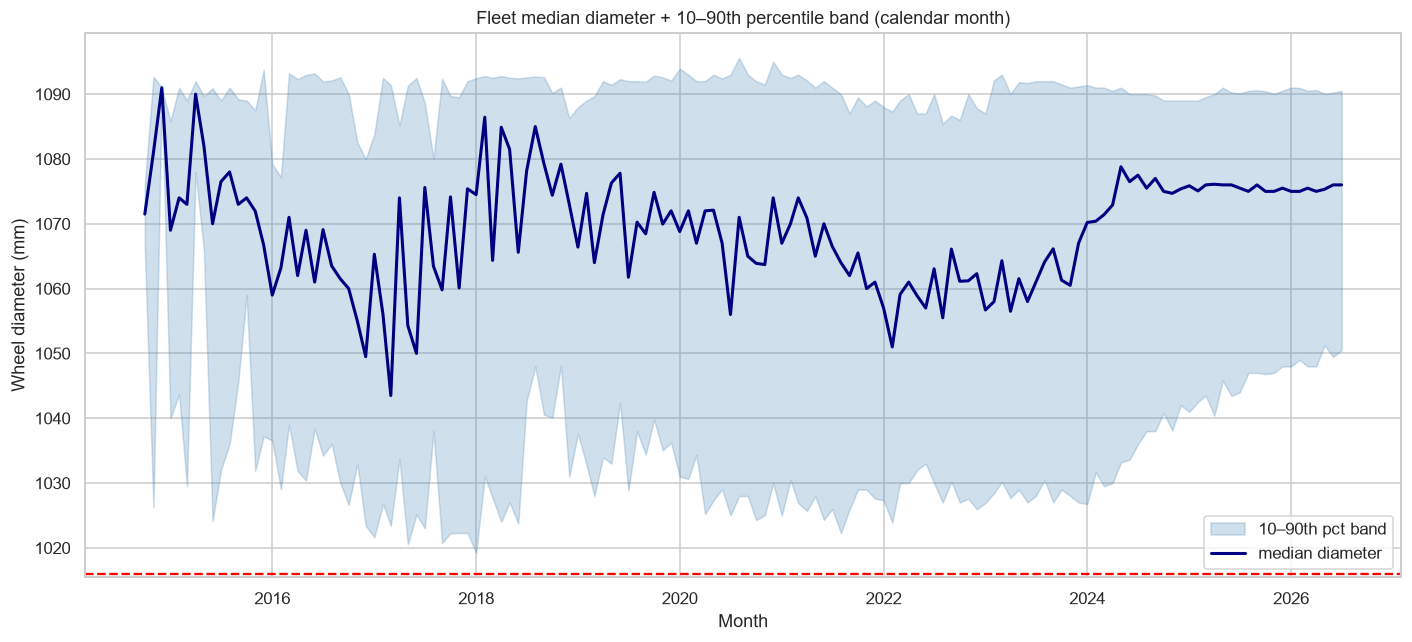

In [13]:
tl_m = timeline.copy()
tl_m["ym"] = tl_m["measurement_timestamp"].dt.to_period("M")
agg = (tl_m.groupby("ym")["dia"]
       .agg(med="median", p10=lambda x: np.percentile(x, 10),
            p90=lambda x: np.percentile(x, 90), n="size").reset_index())
agg["ym"] = agg["ym"].astype(str).astype("datetime64[ns]")

fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(agg["ym"], agg["p10"], agg["p90"], color="steelblue", alpha=0.25,
                label="10–90th pct band")
ax.plot(agg["ym"], agg["med"], color="navy", lw=2, label="median diameter")
ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1.5)
ax.set_title("Fleet median diameter + 10–90th percentile band (calendar month)")
ax.set_xlabel("Month"); ax.set_ylabel("Wheel diameter (mm)")
ax.legend()
plt.tight_layout(); plt.show()


## Section 5 — Diameter vs Distance

Using cumulative RTIS km per locomotive (owner-approved daily aggregation), merged backward
onto each measurement. Only wheelsets with a distance value are shown.

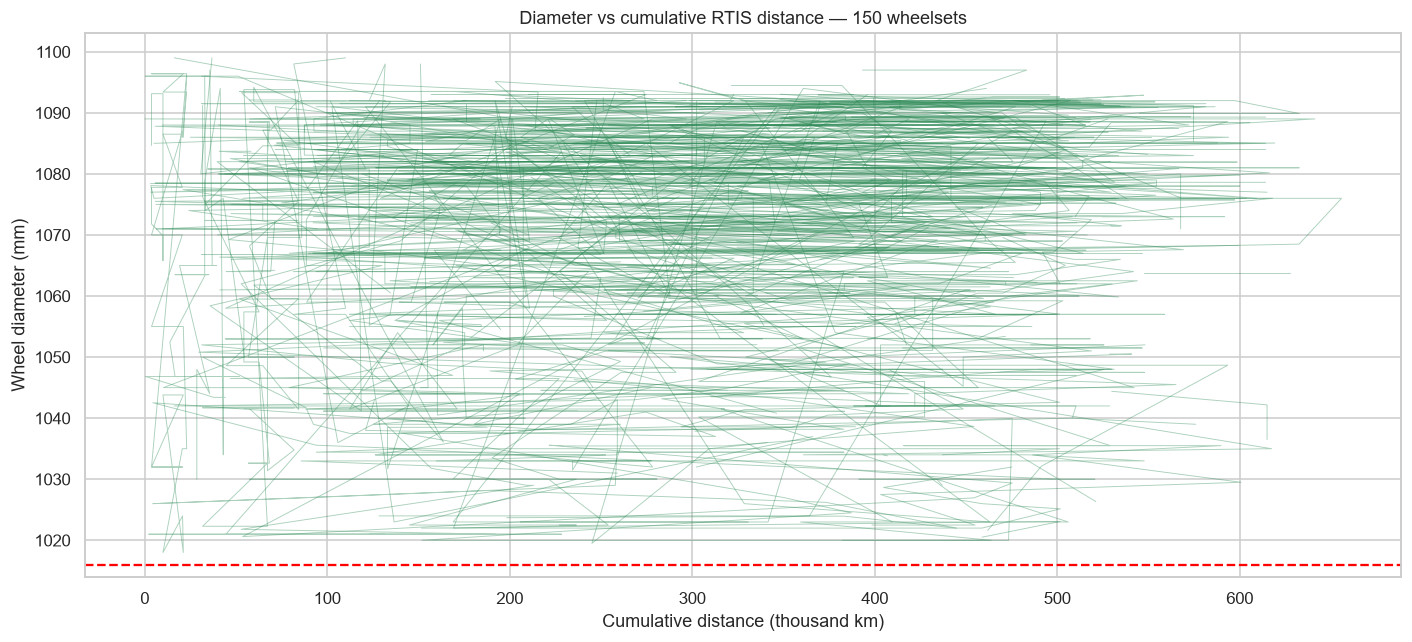

In [14]:
dd = timeline.dropna(subset=["cum_km"]).copy()
dd = dd[dd["cum_km"] > 0]
rng2 = np.random.default_rng(7)
samp_ws2 = rng2.choice(dd["wheelset_equipment_id"].unique(),
                       size=min(150, dd["wheelset_equipment_id"].nunique()), replace=False)

fig, ax = plt.subplots(figsize=(13, 6))
for ws, d in dd[dd["wheelset_equipment_id"].isin(samp_ws2)].groupby("wheelset_equipment_id"):
    ax.plot(d["cum_km"] / 1000, d["dia"], lw=0.6, alpha=0.4, color="seagreen")
ax.axhline(CONDEMN_DIA_REF, color="red", ls="--", lw=1.5)
ax.set_title(f"Diameter vs cumulative RTIS distance — {len(samp_ws2)} wheelsets")
ax.set_xlabel("Cumulative distance (thousand km)"); ax.set_ylabel("Wheel diameter (mm)")
plt.tight_layout(); plt.show()


## Section 6 — Wear rate vs distance (segment-level)

Wear rate per measurement interval **within** a segment (i.e. between turnings, where the wheel
did not turn), expressed as mm per 1000 km. Values above a sanity cap are excluded.

valid segment intervals with distance: 32,942
count    32942.0000
mean         0.0006
std          0.0194
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0001
max          2.8889


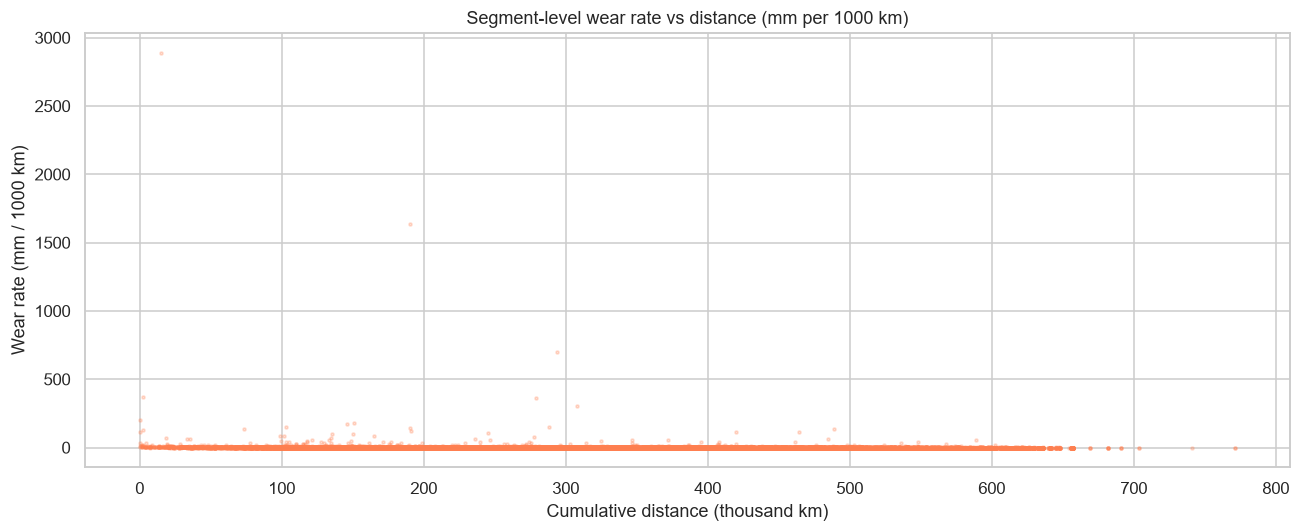

In [15]:
seg = timeline.sort_values(["wheelset_equipment_id", "measurement_timestamp"]).copy()
seg["prev_dia"] = seg.groupby(["wheelset_equipment_id", "seg"])["dia"].shift(1)
seg["prev_km"] = seg.groupby(["wheelset_equipment_id", "seg"])["cum_km"].shift(1)

m = seg.dropna(subset=["prev_dia", "prev_km", "cum_km"]).copy()
m = m[(m["cum_km"] > m["prev_km"]) & (m["prev_dia"] > m["dia"])].copy()
m["wear_mm_per_km"] = (m["prev_dia"] - m["dia"]) / (m["cum_km"] - m["prev_km"])
m = m[np.isfinite(m["wear_mm_per_km"])]
m = m[m["wear_mm_per_km"] < 5]
print(f"valid segment intervals with distance: {len(m):,}")
print(m["wear_mm_per_km"].describe().round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(m["cum_km"] / 1000, m["wear_mm_per_km"] * 1000, s=4, alpha=0.25, color="coral")
ax.set_title("Segment-level wear rate vs distance (mm per 1000 km)")
ax.set_xlabel("Cumulative distance (thousand km)"); ax.set_ylabel("Wear rate (mm / 1000 km)")
plt.tight_layout(); plt.show()


## Section 7 — Remaining material vs distance

Remaining material = diameter − 1016 mm (reference condemn line). Same wheelsets as Section 5.

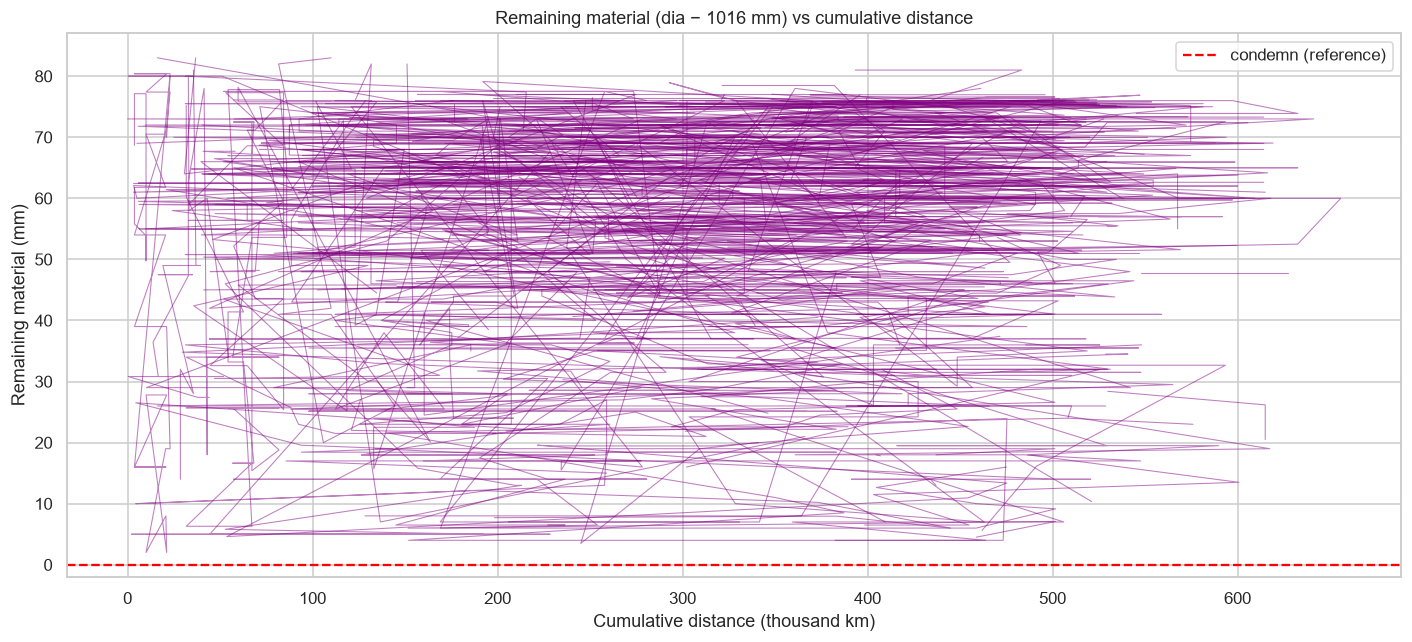

In [16]:
rem = timeline.dropna(subset=["cum_km"]).copy()
rem["remaining_mm"] = rem["dia"] - CONDEMN_DIA_REF
rem = rem[rem["remaining_mm"] > 0]

fig, ax = plt.subplots(figsize=(13, 6))
for ws, d in rem[rem["wheelset_equipment_id"].isin(samp_ws2)].groupby("wheelset_equipment_id"):
    ax.plot(d["cum_km"] / 1000, d["remaining_mm"], lw=0.7, alpha=0.5, color="purple")
ax.axhline(0, color="red", ls="--", lw=1.5, label="condemn (reference)")
ax.set_title("Remaining material (dia − 1016 mm) vs cumulative distance")
ax.set_xlabel("Cumulative distance (thousand km)"); ax.set_ylabel("Remaining material (mm)")
ax.legend()
plt.tight_layout(); plt.show()


## Takeaways

- Wheel life is a **sawtooth**: gradual diameter loss between turnings, with a sudden drop at each
  reprofiling event (median −5 mm), then a new segment. The degradation model and prediction
  intervals operate on these **within-segment** steps (`crosses_reset` excluded) — this notebook is
  the visual confirmation of that structure.
- Turning events are reliably identifiable from `wsmturning1 == 1` (5,246 events; 70.7% coincide
  with a >2 mm diameter drop).
- Distance-based wear is measurable from the approved RTIS daily ledger (~75% coverage on
  measurements); the resulting wear rates are small (order 0.1–1 mm / 1000 km) — consistent with the
  documented ~3 mm measurement noise floor, which is why segment-level (not interval-level) wear is
  the right modelling unit.
- The 1016 mm line is a reference only; official condemning limits are still pending the RDSO
  limit-register approval.